In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import ast # clear product column to get individual products

# TASK 1: DATA PREPARATION
READ DATA, CLEANSE DATA, TRANSFORM DATE AND PRODUCT COLUMNS FOR FURTHER ANALYSES

In [2]:
raw_df = pd.read_csv('Retail_Transactions_Dataset.csv')

## Date transformation
raw_df['Date'] = pd.to_datetime(raw_df['Date']) 
raw_df['Year'] = raw_df['Date'].dt.year
raw_df['Month'] = raw_df['Date'].dt.month
raw_df['DayOfWeekNum'] = raw_df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
raw_df['DayOfWeekName'] = raw_df['Date'].dt.day_name()  # e.g., 'Monday', 'Tuesday'


display(raw_df.head())
print(raw_df.info())
print(raw_df.columns)

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year,Month,DayOfWeekNum,DayOfWeekName
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN,2022,1,4,Friday
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),2023,3,2,Wednesday
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN,2024,3,3,Thursday
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN,2020,10,5,Saturday
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,2020,12,3,Thursday


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Transaction_ID     1000000 non-null  int64         
 1   Date               1000000 non-null  datetime64[us]
 2   Customer_Name      1000000 non-null  str           
 3   Product            1000000 non-null  str           
 4   Total_Items        1000000 non-null  int64         
 5   Total_Cost         1000000 non-null  float64       
 6   Payment_Method     1000000 non-null  str           
 7   City               1000000 non-null  str           
 8   Store_Type         1000000 non-null  str           
 9   Discount_Applied   1000000 non-null  bool          
 10  Customer_Category  1000000 non-null  str           
 11  Season             1000000 non-null  str           
 12  Promotion          666057 non-null   str           
 13  Year               1000000 non-null  in

In [3]:
## Explode the 'Items_Purchased' column to have one item per row
raw_df['product_cleansed'] = raw_df['Product'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df_long = raw_df.explode('product_cleansed').reset_index(drop=True)
df_long['product_cleansed'] = df_long['product_cleansed'].str.strip()  # Remove leading/trailing whitespace

# TASK 2: BASIC EXPLORATION
- Total Unique transactions 
- Total unique products 
- Top 5 products by # unique transactions 
- Top 5 cities by # unique transactions 

In [4]:
raw_df.Transaction_ID.nunique(), raw_df.Customer_Name.nunique()

(1000000, 329738)

In [5]:
df_long.Transaction_ID.nunique(), df_long.Customer_Name.nunique()

(1000000, 329738)

In [6]:
df_long.product_cleansed.nunique()

81

In [7]:
(df_long
 .groupby('product_cleansed',as_index=False)['Transaction_ID']
 .nunique()
 .sort_values(by='Transaction_ID',ascending=False)
 .head(5)
 )

,product_cleansed,Transaction_ID
73,Toothpaste,70949
32,Ice Cream,36485
63,Soap,36438
47,Orange,36342
36,Jam,36336


In [8]:
(raw_df
 .groupby('City',as_index=False)['Transaction_ID']
 .nunique()
 .sort_values(by='Transaction_ID',ascending=False)
 .head(5)
 )

,City,Transaction_ID
1,Boston,100566
3,Dallas,100559
9,Seattle,100167
2,Chicago,100059
4,Houston,100050


# TASK 3: CUSTOMER BEHAVIOUR ANALYSIS

In [9]:
(raw_df
 .groupby('Customer_Category',as_index=False)['Total_Cost']
 .mean()
 .sort_values(by='Total_Cost',ascending=False)
 .rename(columns={'Total_Cost': 'Avg_Spend ($)'})
 .head(5)
 )

,Customer_Category,Avg_Spend ($)
6,Teenager,52.529091
2,Professional,52.525762
5,Student,52.487994
0,Homemaker,52.461417
7,Young Adult,52.448246


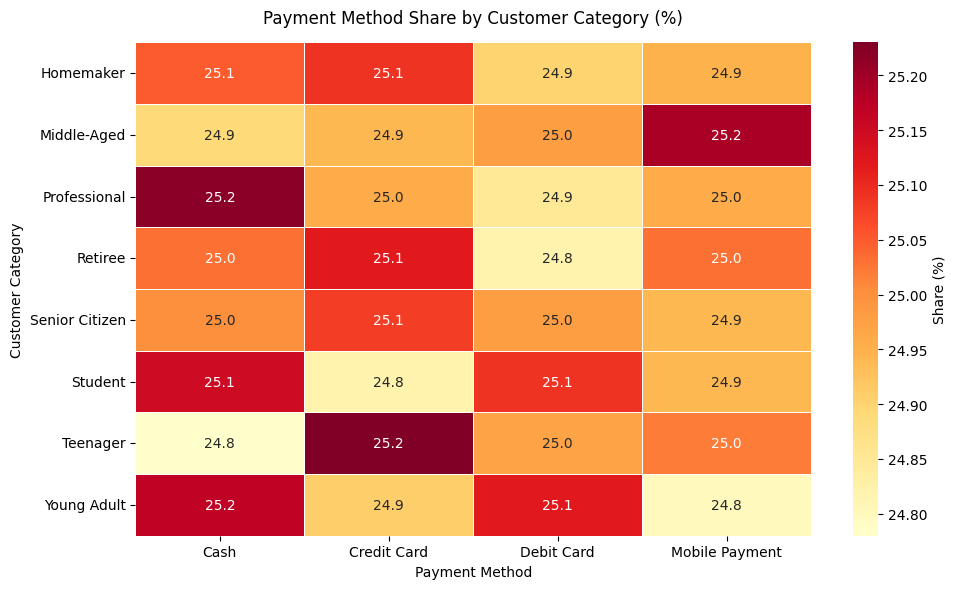

In [10]:
customer_payment = (raw_df
                    .groupby(['Customer_Category','Payment_Method'],as_index=False)['Total_Cost']
                    .sum()
                    .rename(columns={'Total_Cost':'Spend ($)'})
                    .sort_values(by=['Spend ($)','Customer_Category'],ascending=[False,True])
                    .assign(Total=lambda df: df.groupby('Customer_Category')['Spend ($)'].transform('sum'),
                            Percent=lambda df: round(df['Spend ($)']/df['Total']*100, 2)
                            )
                            .pivot(index='Customer_Category',columns='Payment_Method',values='Percent')
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(customer_payment, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Share (%)'})

ax.set_title('Payment Method Share by Customer Category (%)', pad=14)
ax.set_xlabel('Payment Method')
ax.set_ylabel('Customer Category')
plt.tight_layout()
plt.show()

**Inference**
- For each customer category, each payment type varies betweem [24.8%-25.2%]
- No particular inference can be drawn about preference of payment type for any of the customer categories
- May be an artefact of data being synthetic

5.495941
count    1000000.000000
mean           5.495941
std            2.871654
min            1.000000
25%            3.000000
50%            5.000000
75%            8.000000
max           10.000000
Name: Total_Items, dtype: float64


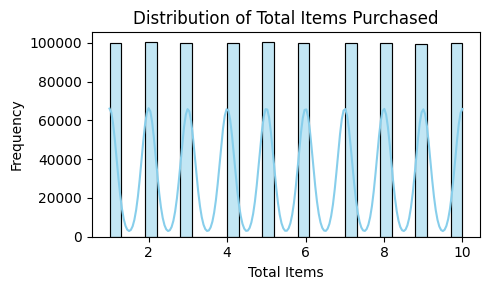

In [11]:
print(raw_df['Total_Items'].mean())
print(raw_df['Total_Items'].describe())
plt.figure(figsize=(5, 3))
sns.histplot(raw_df['Total_Items'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Total Items Purchased')
plt.xlabel('Total Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()  

# TASK 4: PROMOTION & DISCOUNT IMPACT

In [12]:
(
raw_df
    .groupby(['Discount_Applied'],as_index=False)['Total_Cost']
    .mean()
    .sort_values(by='Total_Cost',ascending=False)
    .rename(columns={'Total_Cost': 'Avg_Spend ($)'})
    .head(5)
)

,Discount_Applied,Avg_Spend ($)
1,True,52.486915
0,False,52.423512


In [13]:
(
raw_df
    .groupby(['Promotion'],as_index=False, dropna=False)['Total_Items']
    .mean()
    .sort_values(by='Total_Items',ascending=False)
    .head(5)
)

,Promotion,Total_Items
1,Discount on Selected Items,5.501248
0,BOGO (Buy One Get One),5.494351
2,NaN,5.492228


In [ ]:
(
raw_df
    .groupby(['Promotion'],as_index=False, dropna=False)['Total_Cost']
    .mean()
    .sort_values(by='Total_Cost',ascending=False)
    .rename(columns={'Total_Cost': 'Avg_Spend ($)'})
    .head(5)
)

# TASK 5: SEASONALITY TRENDS

In [14]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}

raw_df['Season'] = raw_df['Month'].map(season_map)

(raw_df
 .groupby(['Season'], as_index=False)['Total_Cost']
 .mean()
 .rename(columns={'Total_Cost': 'Total_Revenue ($)'})
)

,Season,Total_Revenue ($)
0,Autumn,52.503761
1,Spring,52.465529
2,Summer,52.476189
3,Winter,52.383941


In [15]:
display(raw_df
 .groupby(['Year','Season'], as_index=False, dropna=False)['Total_Cost']
 .sum()
 .rename(columns={'Total_Cost': 'Total_Revenue'})
 .sort_values('Total_Revenue', ascending=False)
 .pivot(index='Year', columns='Season', values='Total_Revenue')
)

print('Season with largest revenue:',raw_df[raw_df['Year']<2024] # Dropped since only half year data is available for 2024
 .groupby('Season')['Total_Cost']
 .sum()
 .idxmax()
)

season_revenue = (raw_df
 .groupby('Season', as_index=False)['Total_Cost']
 .mean()
 .rename(columns={'Total_Cost': 'Avg_Revenue'})
 .sort_values('Avg_Revenue', ascending=False)
)

Season,Autumn,Spring,Summer,Winter
Year,,,,
2020,2995528.30,3006027.57,3024056.58,2989938.10
2021,2987087.59,3010187.14,3023404.84,2948231.35
2022,2968883.61,3026463.28,3020000.62,2931685.39
2023,2994261.23,3026975.99,3010300.15,2951990.81
2024,NaN,2583128.75,NaN,1957069.10


Season with largest revenue: Summer


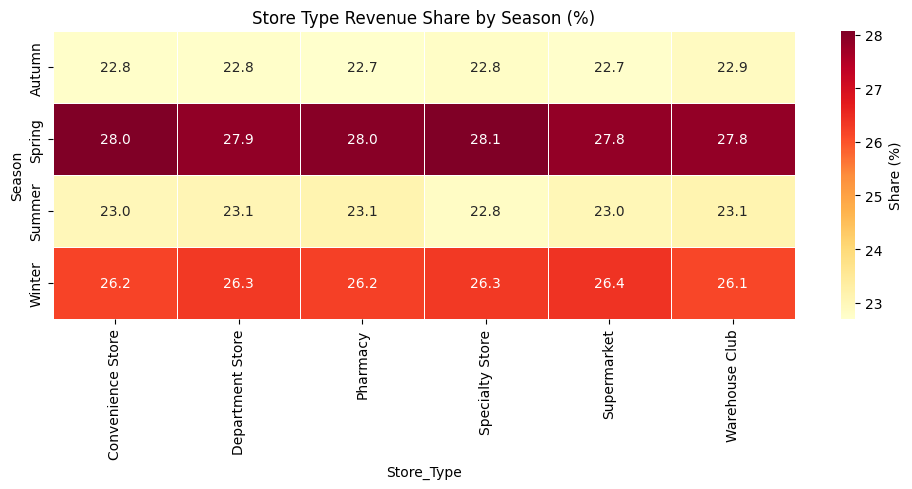

In [16]:
pivot_store = (raw_df
 .groupby(['Season', 'Store_Type'])['Total_Cost']
 .sum()
 .unstack()
 .apply(lambda x: (x / x.sum() * 100).round(2))  # share within each season
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_store, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Share (%)'})
ax.set_title('Store Type Revenue Share by Season (%)')
plt.tight_layout()
plt.show()

In [17]:
top5_per_season = (df_long
 .groupby(['Season', 'product_cleansed'])['Transaction_ID']
 .nunique()
 .reset_index()
 .sort_values(['Season', 'Transaction_ID'], ascending=[True, False])
 .groupby('Season')
 .head(5)
)
top5_per_season

,Season,product_cleansed,Transaction_ID
73,Fall,Toothpaste,17830
35,Fall,Ironing Board,9298
0,Fall,Air Freshener,9188
32,Fall,Ice Cream,9183
51,Fall,Peanut Butter,9183
154,Spring,Toothpaste,17647
144,Spring,Soap,9233
112,Spring,Honey,9185
101,Spring,Deodorant,9162
99,Spring,Cleaning Spray,9161


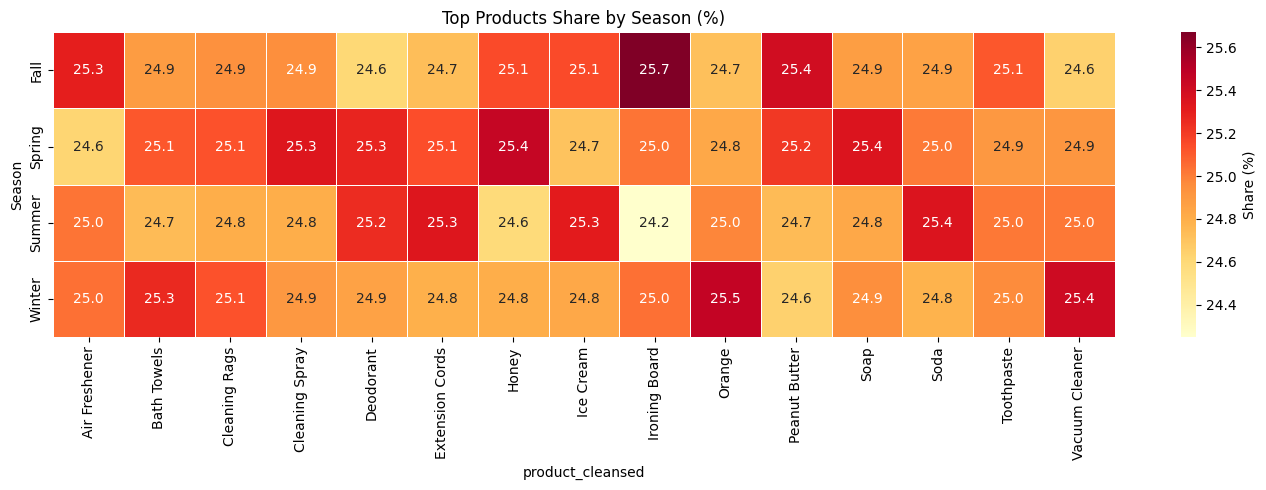

In [18]:
# Union of all top products across seasons
top_products = top5_per_season['product_cleansed'].unique()

pivot_product = (df_long[df_long['product_cleansed'].isin(top_products)]
 .groupby(['Season', 'product_cleansed'])['Transaction_ID']
 .sum()
 .unstack()
 .apply(lambda x: (x / x.sum() * 100).round(2))
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_product, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Share (%)'})
ax.set_title('Top Products Share by Season (%)')
plt.tight_layout()
plt.show()

# TASK 6: VISUALIZATION DASHBOARD

,City,Unique_Transactions
1,Boston,100566
3,Dallas,100559
9,Seattle,100167
2,Chicago,100059
4,Houston,100050


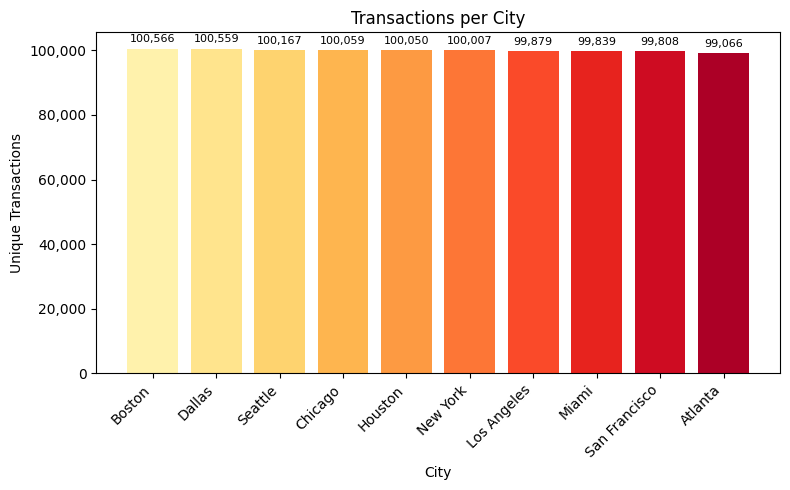

In [19]:
transactions_per_city = (raw_df
                         .groupby('City', as_index=False)['Transaction_ID']
                            .nunique()
                            .rename(columns={'Transaction_ID': 'Unique_Transactions'})
                            .sort_values(by='Unique_Transactions', ascending=False)
)
display(transactions_per_city.head())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(transactions_per_city['City'], transactions_per_city['Unique_Transactions'],
       color=sns.color_palette('YlOrRd', len(transactions_per_city)))

ax.set_title('Transactions per City')
ax.set_xlabel('City')
ax.set_ylabel('Unique Transactions')
ax.bar_label(ax.containers[0],
             labels=[f"{v:,.0f}" for v in transactions_per_city['Unique_Transactions']],
             padding=3, fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

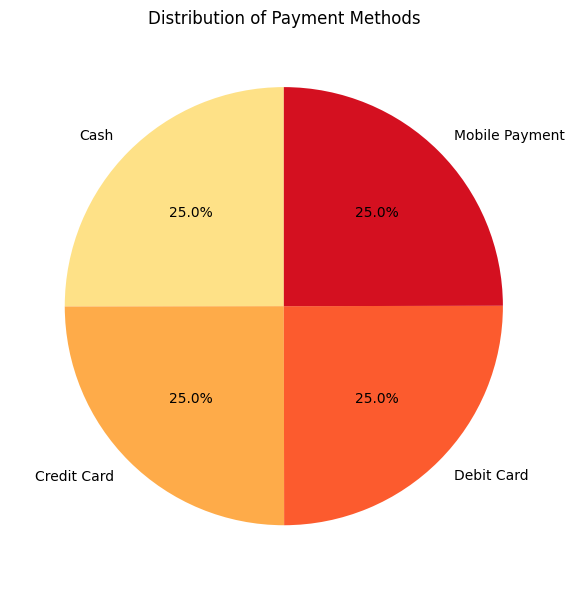

In [20]:
payment_dist = (raw_df
                .groupby('Payment_Method')['Transaction_ID']
                .nunique()
                )

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(payment_dist.values,
       labels=payment_dist.index,
       autopct=lambda p: f'{p:.1f}%',
       colors=sns.color_palette('YlOrRd', len(payment_dist)),
       startangle=90)

ax.set_title('Distribution of Payment Methods')
plt.tight_layout()
plt.show()

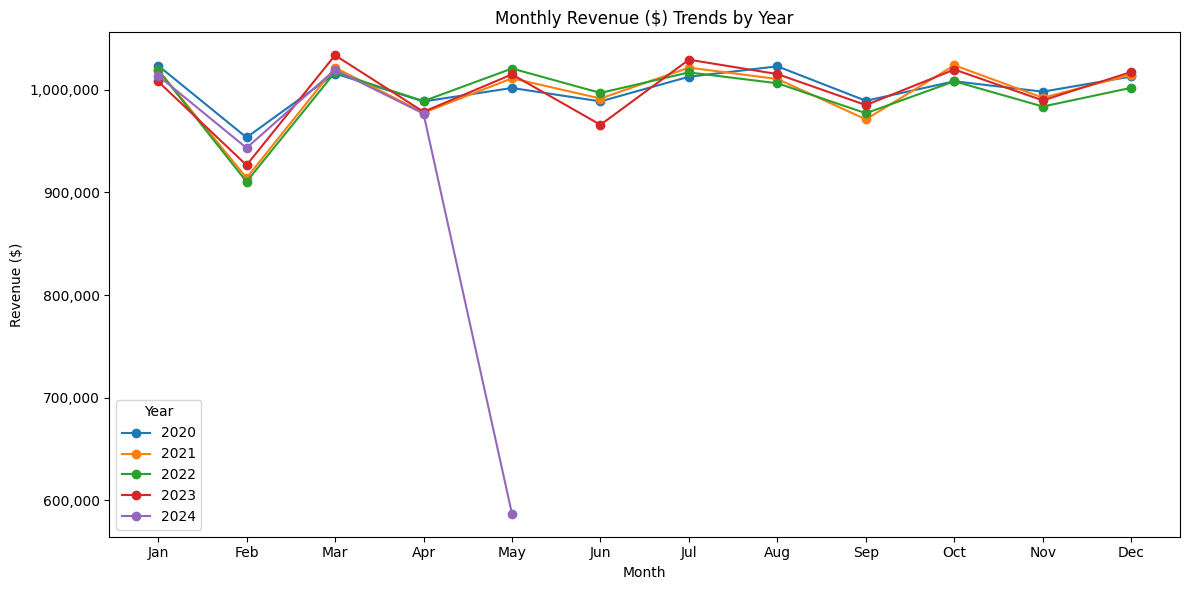

In [21]:
monthly_revenue = (raw_df
                   .groupby(['Year', 'Month'], as_index=False)['Total_Cost']
                   .sum()
                   .rename(columns={'Total_Cost': 'Revenue'})
                   )

fig, ax = plt.subplots(figsize=(12, 6))
for year, grp in monthly_revenue.groupby('Year'):
    ax.plot(grp['Month'], grp['Revenue'], marker='o', label=str(year))

ax.set_title('Monthly Revenue ($) Trends by Year')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title='Year')
plt.tight_layout()
plt.show()

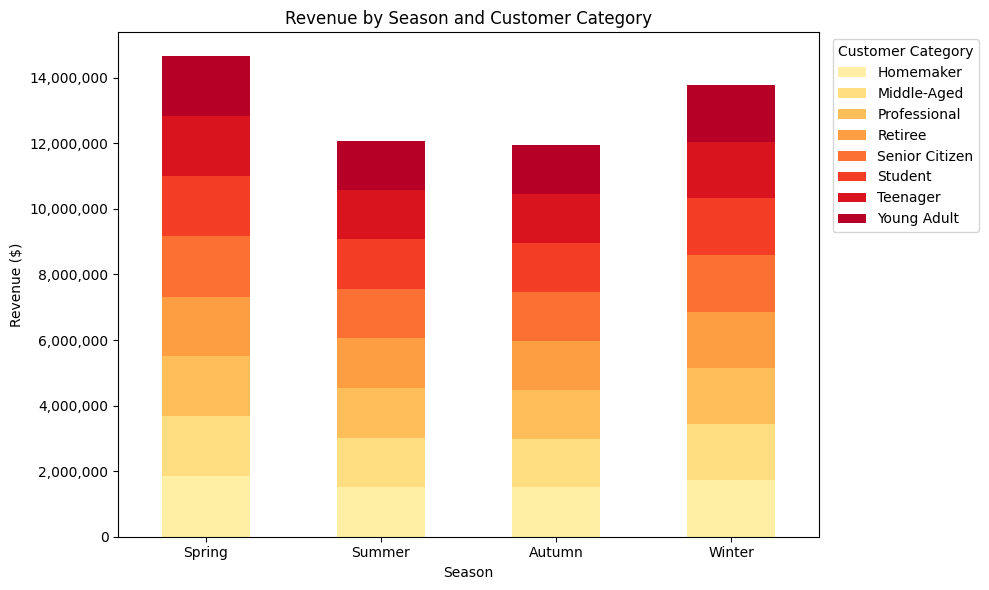

In [22]:
season_category = (raw_df
                   .groupby(['Season', 'Customer_Category'])['Total_Cost']
                   .sum()
                   .unstack()
                   )

# order seasons naturally
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_category = season_category.reindex(season_order)

fig, ax = plt.subplots(figsize=(10, 6))
season_category.plot(kind='bar', stacked=True,
                     color=sns.color_palette('YlOrRd', len(season_category.columns)),
                     ax=ax)

ax.set_title('Revenue by Season and Customer Category')
ax.set_xlabel('Season')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title='Customer Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# COMPUTATION FOR SUMMARY

In [ ]:
print('Total transactions in the dataset: ',raw_df.Transaction_ID.nunique())
print('Total unique customers in the dataset: ',raw_df.Customer_Name.nunique())
print('Total unique products in the dataset: ',df_long['product_cleansed'].nunique())
print('Total unique cities in the dataset: ',raw_df['City'].nunique())

In [ ]:
(raw_df
 .groupby(['Year'],as_index=False)['Transaction_ID']
 .nunique()
 .rename(columns={'Transaction_ID': 'Number_of_Transactions'})
 )

In [ ]:
(raw_df
 .groupby(['Customer_Category'],as_index=False)['Total_Cost']
 .sum()
 .sort_values(by='Total_Cost', ascending=False)
 .rename(columns={'Total_Cost': 'Total_Revenue ($)'})
 )

In [ ]:
(raw_df
 .groupby(['Store_Type'],as_index=False)['Total_Cost']
 .sum()
 .sort_values(by='Total_Cost', ascending=False)
 .rename(columns={'Total_Cost': 'Total_Revenue ($)'})
 )

In [ ]:
(df_long
 .groupby(['product_cleansed'],as_index=False)['Transaction_ID']
 .nunique()
 .sort_values(by='Transaction_ID', ascending=False)
 .rename(columns={'Transaction_ID': 'Unique_transactions'})
 .head()
 )

In [ ]:

from IPython.display import Markdown

# ── Dataset Overview ─────────────────────────────────────────────────────────
total_txns      = raw_df['Transaction_ID'].nunique()
year_min        = int(raw_df['Year'].min())
year_max        = int(raw_df['Year'].max())
num_years       = year_max - year_min + 1
txns_per_year_k = total_txns / num_years / 1_000

# ── Seasonality ──────────────────────────────────────────────────────────────
season_rev_m     = raw_df.groupby('Season')['Total_Cost'].sum() / 1e6
top_season       = season_rev_m.idxmax()
top_season_rev_m = season_rev_m.max()
mean_season_m    = season_rev_m.mean()

# ── Payment Methods ───────────────────────────────────────────────────────────
pm_counts  = raw_df.groupby('Payment_Method')['Transaction_ID'].nunique()
pm_list    = ', '.join(sorted(pm_counts.index))
num_pm     = len(pm_counts)
avg_pm_pct = (pm_counts / pm_counts.sum() * 100).mean()

# ── Geography ─────────────────────────────────────────────────────────────────
city_txns   = raw_df.groupby('City')['Transaction_ID'].nunique().sort_values(ascending=False)
top_city1   = city_txns.index[0]
top_city2   = city_txns.index[1]
top_city1_k = city_txns.iloc[0] / 1_000
top_city2_k = city_txns.iloc[1] / 1_000

# ── Customer Categories ────────────────────────────────────────────────────────
cat_rev      = raw_df.groupby('Customer_Category')['Total_Cost'].sum().sort_values(ascending=False)
top_cat      = cat_rev.index[0]
top_cat_m    = cat_rev.iloc[0] / 1e6
cat_spread_k = (cat_rev.max() - cat_rev.min()) / 1_000

# ── Store Types ───────────────────────────────────────────────────────────────
store_rev   = raw_df.groupby('Store_Type')['Total_Cost'].sum().sort_values(ascending=False)
top_store   = store_rev.index[0]
top_store_m = store_rev.iloc[0] / 1e6
avg_items   = raw_df['Total_Items'].mean()

# ── Products ──────────────────────────────────────────────────────────────────
prod_counts = (df_long.groupby('product_cleansed')['Transaction_ID']
               .nunique().sort_values(ascending=False))
top_prod    = prod_counts.index[0]
top_prod_k  = prod_counts.iloc[0] / 1_000
runner_k    = prod_counts.iloc[1] / 1_000
ratio       = top_prod_k / runner_k
other_prods = ', '.join(prod_counts.index[1:5])

Markdown(f"""
# SUMMARY
**Dataset Overview**
- {total_txns:,.0f} transactions spanning {year_min}–{year_max} across multiple cities, store types, and customer segments.
- That translates to ~{txns_per_year_k:.0f}K transactions per year

**Revenue & Seasonality**
- Revenue is remarkably consistent across all seasons (~${mean_season_m:.2f}M each), suggesting no strong seasonal demand shift overall.
- {top_season} edges slightly ahead at ${top_season_rev_m:.2f}M.

**Payment Methods**
- All {num_pm} payment methods ({pm_list}) are used almost equally (~{avg_pm_pct:.0f}% each), indicating no dominant preference.

**Geography**
- {top_city1} and {top_city2} lead in transaction volume (~{top_city1_k:.1f}K and ~{top_city2_k:.1f}K respectively), but all cities are closely matched — no single city dominates.

**Customer Categories**
- {top_cat}s generate the most revenue (${top_cat_m:.2f}M), but again all segments are tightly clustered within ~${cat_spread_k:.0f}K of each other — no standout category.

**Store Types**
- {top_store} leads revenue slightly (${top_store_m:.2f}M), but all store types perform within 1% of each other.
- Average items per transaction is consistently ~{avg_items:.1f} across all store types.

**Products**
- {top_prod} is by far the most purchased product ({top_prod_k:.0f}K items) — nearly {ratio:.0f}x any other product.
- {other_prods} follow at ~{runner_k:.0f}K each.

**Overall Pattern**
The dataset is highly balanced by design — revenue, transactions, and customer behaviour are uniformly distributed across most dimensions. The main standout is {top_prod}'s outsized purchase volume.
""")
